# Walking nudge method: refine coefficients with small changes

We have a set of 100 good sets of coefficients from the genetic algorithm. We expect that they can be improved with slight adjustments to the coefficient values. In this notebook we find a way to try all sensible combinations of nudging the values of the coefficients.

The previous notebook showed that there are better solutions available by trying a few at random. It also showed that we can't simplify the problem by optimising for deprivation level and age band separately, as accuracy in both measures is needed to achieve a good overall fitness. We want to try every sensible combination rather than nudging values at random to make sure we don't miss any good options. To try every combination of nudges for all 25 coefficients there are 5^25 = 3x10^17 (three hundred quadrillion) options, and lots of those options are probably rubbish - for example, we expect that nudging all or most values upwards will worsen the fit overall, so there's no sense in calculating those options. We need to find a way to select only sensible options and so slash the number of combinations that we need to try.

In this notebook we find a way to try all of the sensible nudges to the coefficients. 

The motivation behind the method is:

+ assume that the starting values are pretty good fits to the data, so
+ increasing or decreasing the value of only one coefficient is bound to make the fitness worse, and
+ the fitness overall might stay at the same level if we simultaneously increase one coefficient (to increase total admissions) and decrease another (to decrease total admissions).

The best chance of a good result is to keep the total admissions from all age bands or all deprivation levels about the same, but to shift the admissions to different age bands or to different deprivation levels. This can be achieved by increasing one coefficient and decreasing another in the same row or the same column when the 25 coefficients are arranged in a 5x5 grid.

By sticking to this principle, we only need to check the nudges to all pairs of coefficients that share a row or a column. Then we can pick the change that results in the best fitness and discard the other worse options. Then we find another change to improve fitness, and so on until no more improvements can be found. 

__Inputs__

+ MSOA-level admission numbers, numbers of people in each age band.
+ Probability of stroke given age band, i.e. SSNAP-derived coefficients
+ Total number of admissions in each age band from SSNAP
+ 100 sets of "best" coefficients from 100 runs of the genetic algorithm

__Method__

1. Make a list of the 200 pairs of coefficients. A pair cannot contain the same coefficient twice. The two orders are counted separately, i.e. coefficients A and B are paired up once as (A, B) and once as (B, A). The two paired coefficients must be in either the same row or the same column of the 5x5 grid.
1. Take the set of coefficients.
4. Calculate 250 sets of nudged coefficients. This is 200 sets where the first in the pair is increased by 1 significant figure and the second in the pair is decreased by the same. There are a further 25 sets where only one coefficient is increased, and yet another 25 sets where only one coefficient is decreased.
5. Calculate the fitnesses of the 250 sets of nudged coefficients.
6. Keep the set with the best fitness. Discard the rest.
7. Return to step 2 _unless_ the same set of best coefficients has been picked twice, in which case there are no more improvements to be made.

This means that in each pass, we try a number of combinations that are quite close to the starting values. We prioritise changes that result in better fitness than the starting point, discarding changes that are worse, and iteratively make changes to find the best combination of coefficients near the start values.

We apply this walking nudge method to each of the 100 sets of coefficients from the runs of the genetic algorithm, and so find the best set of coefficients that is near to those starting points.

__Results__

2 of the 100 sets converge on one set of values that have better fitness than the other sets manage. Go with these as the "best" values.

In [1]:
import polars as pl
import os
import numpy as np
import itertools
import matplotlib.pyplot as plt

# Print general numbers, not scientific notation:
np.set_printoptions(suppress=True)

## Load data

### Admissions

In [2]:
path_to_msoa_stats = os.path.join('data', 'msoa_cleaned.csv')

df_stats = pl.read_csv(path_to_msoa_stats)

In [3]:
df_stats.head()

MSOA,admissions,IMD2019Score,All persons,country,good_health,fair health,bad health,prop_good_health,prop_fair health,prop_bad health,MSOA11CD,age_65_proportion,age_70_proportion,age_75_proportion,age_less65_proportion,age_over80_proportion,total_health,age_less65,age_65,age_70,age_75,age_over80,depriv_quantile_min,depriv_quantile_max
str,f64,f64,i64,str,i64,i64,i64,f64,f64,f64,str,f64,f64,f64,f64,f64,i64,f64,f64,f64,f64,f64,f64,f64
"""Adur 001""",14.333333,16.924833,8815,"""E""",6799,1251,474,0.79763,0.146762,0.055608,"""E02006534""",0.0559,0.0528,0.0422,0.7872,0.062,8524,6939.168,492.7585,465.432,371.993,546.53,0.4,0.6
"""Adur 002""",7.333333,6.4704,7263,"""E""",5537,838,259,0.83464,0.126319,0.039041,"""E02006535""",0.0578,0.0774,0.0492,0.7467,0.0692,6634,5423.2821,419.8014,562.1562,357.3396,502.5996,0.8,1.0
"""Adur 003""",9.333333,13.7334,7354,"""E""",5820,969,311,0.819718,0.136479,0.043803,"""E02006536""",0.0609,0.0582,0.0421,0.7729,0.0661,7100,5683.9066,447.8586,428.0028,309.6034,486.0994,0.6,0.8
"""Adur 004""",21.0,26.199857,10582,"""E""",7872,1546,709,0.777328,0.152661,0.070011,"""E02006537""",0.0465,0.0438,0.0367,0.8091,0.0638,10127,8561.8962,492.063,463.4916,388.3594,675.1316,0.2,0.4
"""Adur 005""",13.666667,11.7948,9059,"""E""",7106,1081,339,0.833451,0.126789,0.039761,"""E02006538""",0.0597,0.067,0.0425,0.7643,0.0662,8526,6923.7937,540.8223,606.953,385.0075,599.7058,0.6,0.8


Pick out column names for the health and age proportions:

In [4]:
props_age = [
    'age_less65_proportion', 'age_65_proportion', 'age_70_proportion',
    'age_75_proportion', 'age_over80_proportion'
]
age_numbers = [p.replace('_proportion', '') for p in props_age]
qmin_list = sorted(df_stats['depriv_quantile_min'].unique())

# Names of coeffs:
coeff_names = [f'{a}_q{str(round(q, 1)).replace(".", "")}'
               for q in qmin_list for a in age_numbers]
# Check the first few:
print(coeff_names[:3])

# Quantile names:
quantile_str_list = sorted(list(set([c.split('_')[-1] for c in coeff_names])))

['age_less65_q00', 'age_65_q00', 'age_70_q00']


Gather admissions data by deprivation quantile:

In [5]:
admissions_lists = []
x_lists = []

for qmin in qmin_list:
    df_stats_here = df_stats.filter(df_stats['depriv_quantile_min'] == qmin)
    # MSOA data in the same order as those coefficients:
    x_lists_here = [df_stats_here[a] for a in age_numbers]
    admissions_here = df_stats_here['admissions'].to_numpy().tolist()
    # Store:
    admissions_lists.append(admissions_here)
    x_lists.append(x_lists_here)

### Age-admissions coefficients

Starting SSNAP coefficients:

In [6]:
df_pop_admissions = pl.read_csv(os.path.join('outputs', 'ssnap_coeffs.csv'))

In [7]:
df_pop_admissions

Age Groups,population,prop_of_all_pop,count,prop_of_all_admissions,admissions_annual,admissions_annual_boost,prob_stroke_given_age
str,i64,f64,i64,f64,f64,f64,f64
"""Under 65""",45933245,0.816055,38827,0.231449,12942.33333,18737.66819,0.000408
"""65-69""",2796740,0.049687,15324,0.091347,5108.0,7395.26689,0.002644
"""70-74""",2779326,0.049378,21508,0.12821,7169.33333,10379.62674,0.003735
"""75-79""",1940686,0.034478,24150,0.143959,8050.0,11654.63948,0.006005
"""80 and over""",2836964,0.050402,67947,0.405035,22649.0,32790.7987,0.011558


Pick out SSNAP coefficients:

In [8]:
coeffs_ssnap = df_pop_admissions['prob_stroke_given_age'].to_numpy()

coeffs_ssnap

array([0.000408, 0.002644, 0.003735, 0.006005, 0.011558])

Turn them into a dictionary:

In [9]:
labels = ['less65', '65', '70', '75', 'over80']
coeffs_ssnap_dict = (
    dict(zip(labels, df_pop_admissions['prob_stroke_given_age'].to_numpy())))

coeffs_ssnap_dict

{'less65': 0.000408,
 '65': 0.002644,
 '70': 0.003735,
 '75': 0.006005,
 'over80': 0.011558}

Pick out admissions numbers:

In [10]:
admissions_by_age = (
    df_pop_admissions['admissions_annual_boost'].to_numpy().flatten())

### Best results from genetic algorithm

Data stored as scale factors for the SSNAP-derived coefficients.

In [11]:
df_best_gens = pl.read_csv(os.path.join('outputs', 'best_inds_deap.csv'))

In [12]:
df_best_gens.head()

dir,# gen,age_less65_q00,age_65_q00,age_70_q00,age_75_q00,age_over80_q00,age_less65_q02,age_65_q02,age_70_q02,age_75_q02,age_over80_q02,age_less65_q04,age_65_q04,age_70_q04,age_75_q04,age_over80_q04,age_less65_q06,age_65_q06,age_70_q06,age_75_q06,age_over80_q06,age_less65_q08,age_65_q08,age_70_q08,age_75_q08,age_over80_q08,fitness,r2_all,r2_q00,r2_q02,r2_q04,r2_q06,r2_q08
str,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
"""randomseed00""",33.0,1.3,1.2,1.332,1.237,1.2,1.026,1.145,1.151,1.041,1.1,1.0,1.0,0.988,0.938,1.0,0.862,0.9,0.945,0.938,0.937,0.8,0.9,0.732,0.832,0.874,238.372,0.584365,0.502719,0.579147,0.616005,0.598245,0.606993
"""randomseed01""",33.0,1.1,1.3,1.305,1.3,1.231,1.1,1.1,1.1,1.023,1.1,1.0,1.0,1.0,1.0,1.0,0.969,0.9,0.9,0.892,0.9,0.837,0.849,0.8,0.8,0.894,238.507,0.575882,0.471584,0.579147,0.616005,0.583824,0.606993
"""randomseed02""",43.0,1.273,1.308,1.175,1.2,1.214,0.981,1.1,1.103,1.1,1.131,0.949,0.987,1.046,1.0,1.0,0.949,0.979,0.896,0.9,0.9,0.844,0.773,0.861,0.8,0.88,238.037,0.58383,0.485431,0.583466,0.616005,0.606683,0.606993
"""randomseed03""",28.0,1.171,1.3,1.327,1.186,1.3,1.1,1.198,1.1,1.1,1.1,1.042,1.0,1.0,1.0,0.971,0.881,0.9,0.894,1.0,0.9,0.8,0.771,0.808,0.7,0.9,239.49,0.585993,0.508469,0.583466,0.631482,0.605116,0.580367
"""randomseed04""",39.0,1.2,1.2,1.25,1.225,1.293,1.1,1.1,1.11,1.069,1.1,0.976,1.019,1.0,1.0,0.961,0.925,0.904,0.9,0.915,0.91,0.8,0.9,0.844,0.8,0.879,238.453,0.591769,0.508469,0.579147,0.631482,0.612783,0.606993


Convert the scale factors to the actual age-deprivation coefficient values using the SSNAP coefficients.

In [13]:
for coeff in coeff_names:
    key = coeff.split('_')[1]
    new_data = df_best_gens[coeff] * coeffs_ssnap_dict[key]
    
    df_best_gens = df_best_gens.with_columns(pl.Series(coeff, new_data))

Round results:

In [14]:
# Set up dictionary with how many decimal places to round to:
labels = ['less65', '65', '70', '75', 'over80']
round_dict = dict(zip(labels, [4, 3, 3, 3, 3]))

for coeff in coeff_names:
    key = coeff.split('_')[1]
    new_data = np.round(df_best_gens[coeff], round_dict[key])
    
    df_best_gens = df_best_gens.with_columns(pl.Series(coeff, new_data))

Drop the measures of goodness of fit now that the coefficients have been rounded:

In [15]:
df_best_gens = df_best_gens.drop(
    ['fitness'] + [c for c in df_best_gens.columns if c.startswith('r2')])

## Recalculate fitness

Use similar functions to previous notebooks to calculate sum of square residuals and fitness.

In [16]:
def predict_admissions(x_lists, coeffs):
    """
    x_lists: np.array.
    coeffs: np.array.
    
    Have to have same number of coeffs as x_lists.
    """
    # Predicted admissions:
    # yhat = (x_lists * coeffs.reshape(len(coeffs), 1)).sum(axis=0)
    yhat = sum(
        [x_lists[i] * coeffs[i] for i in range(len(coeffs))]
    )
    return yhat.to_numpy().tolist()

In [17]:
def predict_admissions_each_age(x_lists, coeffs):
    """
    x_lists: np.array.
    coeffs: np.array.
    
    Have to have same number of coeffs as x_lists.
    """
    # Predicted admissions:
    yhat = (
        [(x_lists[i] * coeffs[i]).sum() for i in range(len(coeffs))]
    )
    return yhat

Goodness check option 1: This calculates the sum of the square of the differences between predicted and actual admission numbers:

In [18]:
def find_square_residuals(yhat, y):
    # Difference from actual:
    sqres = (np.array(yhat) - np.array(y))**2.0
    # Sum of differences:
    sum_sqres = sqres.sum()
    return np.sqrt(sum_sqres)

In [19]:
def many_sum_sqres(individual, x_lists, admissions_lists):
    # Predictions for each MSOA:
    predictions_lists = []
    sum_sqres_by_depriv = []
    for i in range(5):
        coeffs = individual[(i*5):(i*5)+5]  # coeffs for this depriv.
        yhat = predict_admissions(x_lists[i], coeffs)
        sum_sqres = find_square_residuals(yhat, admissions_lists[i])
        predictions_lists.append(yhat)
        sum_sqres_by_depriv.append(sum_sqres)


    # Combine lists:
    observed_all = sum(admissions_lists, [])
    predicted_all = sum(predictions_lists, [])
    # Calculate sum of square residuals across all MSOA:
    sum_sqres = find_square_residuals(predicted_all, observed_all)

    return sum_sqres, sum_sqres_by_depriv

In [20]:
# the goal ('fitness') function to be maximized
def eval_admissions(individual, admissions_lists, x_lists, admissions_by_age):

    # Predictions for each age band across England:
    predictions_by_age = [0.0] * 5
    for i in range(5):
        # Population numbers for areas in this quantile:
        x_lists_here = x_lists[i]
        # Separate prediction for each deprivation quantile:
        coeffs = individual[(i*5):(i*5)+5] #* np.array(coeffs_ssnap)
        yhat_list = predict_admissions_each_age(x_lists_here, coeffs)
        # predictions_lists.append(yhat)
        for j, y in enumerate(yhat_list):
            predictions_by_age[j] += y
    # Divide the admissions by age band by the observed values:
    for j in range(len(predictions_by_age)):
        predictions_by_age[j] /= admissions_by_age[j]
    # Wrongness ratio factor:
    rat = sum(np.abs(np.array(predictions_by_age) - 1.0)) + 1.0

    sum_sqres, sum_sqres_by_depriv = many_sum_sqres(individual, x_lists, admissions_lists)
    
    return (sum_sqres, rat, sum_sqres * rat, predictions_by_age, sum_sqres_by_depriv)

In [21]:
def eval_fitness_to_df(df_best_gens, admissions_lists, x_lists, admissions_by_age, coeff_names, concat=False):
    eval_dict = {}
    eval_labels = [
        'sum_sqres',
        'wrong_rat',
        'fitness',
        'wrong_rat_under65',
        'wrong_rat_65',
        'wrong_rat_70',
        'wrong_rat_75',
        'wrong_rat_over80',
        'sum_sqres_q00',
        'sum_sqres_q02',
        'sum_sqres_q04',
        'sum_sqres_q06',
        'sum_sqres_q08',
    ]
    eval_dict = dict(zip(eval_labels, [[] for e in eval_labels]))
    
    for d in range(len(df_best_gens)):
        df = df_best_gens[d]
        # Pick out coefficients:
        coeffs = df[coeff_names].to_numpy().flatten()
        sum_sqres, rat, fitness, ratios_by_age, sum_sqres_by_depriv = eval_admissions(
            coeffs,
            admissions_lists,
            x_lists,
            admissions_by_age
        )
        eval_dict['sum_sqres'].append(sum_sqres)
        eval_dict['wrong_rat'].append(rat)
        eval_dict['fitness'].append(fitness)
        eval_dict['wrong_rat_under65'].append(ratios_by_age[0])
        eval_dict['wrong_rat_65'].append(ratios_by_age[1])
        eval_dict['wrong_rat_70'].append(ratios_by_age[2])
        eval_dict['wrong_rat_75'].append(ratios_by_age[3])
        eval_dict['wrong_rat_over80'].append(ratios_by_age[4])
        eval_dict['sum_sqres_q00'].append(sum_sqres_by_depriv[0])
        eval_dict['sum_sqres_q02'].append(sum_sqres_by_depriv[1])
        eval_dict['sum_sqres_q04'].append(sum_sqres_by_depriv[2])
        eval_dict['sum_sqres_q06'].append(sum_sqres_by_depriv[3])
        eval_dict['sum_sqres_q08'].append(sum_sqres_by_depriv[4])

    # Either start a new blank dataframe or add the fitnesses to the
    # input df:
    df_new = df_best_gens if concat else pl.DataFrame()
    for key, v in eval_dict.items():
        df_new = df_new.with_columns(pl.Series(key, v))
    return df_new

Recalculate fitnesses for the genetic algorithm outputs:

In [22]:
df_best_gens = eval_fitness_to_df(df_best_gens, admissions_lists, x_lists, admissions_by_age, coeff_names, concat=True)

View results:

In [23]:
df_best_gens.sort('fitness').head()

dir,# gen,age_less65_q00,age_65_q00,age_70_q00,age_75_q00,age_over80_q00,age_less65_q02,age_65_q02,age_70_q02,age_75_q02,age_over80_q02,age_less65_q04,age_65_q04,age_70_q04,age_75_q04,age_over80_q04,age_less65_q06,age_65_q06,age_70_q06,age_75_q06,age_over80_q06,age_less65_q08,age_65_q08,age_70_q08,age_75_q08,age_over80_q08,sum_sqres,wrong_rat,fitness,wrong_rat_under65,wrong_rat_65,wrong_rat_70,wrong_rat_75,wrong_rat_over80,sum_sqres_q00,sum_sqres_q02,sum_sqres_q04,sum_sqres_q06,sum_sqres_q08
str,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
"""randomseed74""",22.0,0.0005,0.004,0.004,0.007,0.014,0.0004,0.003,0.004,0.007,0.013,0.0004,0.003,0.004,0.006,0.012,0.0004,0.002,0.004,0.005,0.01,0.0003,0.002,0.003,0.005,0.01,239.191107,1.055834,252.546109,0.980725,1.01735,1.013293,0.99959,0.994494,111.087199,107.849722,108.96863,104.473782,102.232696
"""randomseed10""",26.0,0.0005,0.004,0.005,0.007,0.014,0.0004,0.003,0.004,0.007,0.013,0.0004,0.003,0.004,0.006,0.012,0.0004,0.002,0.003,0.005,0.01,0.0003,0.002,0.003,0.005,0.01,240.357618,1.052517,252.980542,0.980725,1.01735,0.990024,0.99959,0.994494,110.501962,107.849722,108.96863,107.721177,102.232696
"""randomseed94""",18.0,0.0005,0.004,0.005,0.007,0.014,0.0004,0.003,0.004,0.007,0.013,0.0004,0.003,0.004,0.006,0.012,0.0004,0.002,0.003,0.005,0.011,0.0003,0.002,0.003,0.005,0.01,238.67206,1.061548,253.361768,0.980725,1.01735,0.990024,0.99959,1.014536,110.501962,107.849722,108.96863,103.905822,102.232696
"""randomseed26""",20.0,0.0005,0.004,0.005,0.008,0.014,0.0004,0.003,0.004,0.006,0.014,0.0004,0.003,0.004,0.006,0.011,0.0004,0.002,0.003,0.005,0.01,0.0003,0.002,0.003,0.005,0.01,239.532221,1.061076,254.161938,0.980725,1.01735,0.990024,0.994136,0.991389,110.922311,107.800573,106.750111,107.721177,102.232696
"""randomseed57""",56.0,0.0005,0.004,0.005,0.007,0.014,0.0004,0.003,0.004,0.006,0.013,0.0004,0.003,0.004,0.006,0.012,0.0004,0.002,0.003,0.006,0.01,0.0003,0.002,0.003,0.005,0.01,239.371525,1.062211,254.262948,0.980725,1.01735,0.990024,1.010103,0.994494,110.501962,108.40745,108.96863,104.929413,102.232696


Pick out the best coeffs so far:

In [24]:
df_coeffs_best_deap = df_best_gens.sort('fitness')[0]
coeffs_best_deap = df_coeffs_best_deap[coeff_names].to_numpy().flatten()

## Set up pairs of coefficients

Set up coefficient locations/indices in the format (row number, column number):

In [25]:
row_col_inds = [c for c in itertools.product(range(5), repeat=2)]

row_col_inds

[(0, 0),
 (0, 1),
 (0, 2),
 (0, 3),
 (0, 4),
 (1, 0),
 (1, 1),
 (1, 2),
 (1, 3),
 (1, 4),
 (2, 0),
 (2, 1),
 (2, 2),
 (2, 3),
 (2, 4),
 (3, 0),
 (3, 1),
 (3, 2),
 (3, 3),
 (3, 4),
 (4, 0),
 (4, 1),
 (4, 2),
 (4, 3),
 (4, 4)]

The following function finds all pairs of coefficients that share a row or column:

In [26]:
def build_pairs(row_col_inds):
    """
    Find a list of pairs of coefficient indices.

    Excludes pairs with the same coefficient twice.

    Inputs
    ------
    row_col_inds - list. List of tuple/list, one pair of numbers for
                   each coefficient's row then column index.

    Returns
    -------
    pairs_list - list. Each item is a tuple of two tuples, and each
                 of the inner tuples is a row then column index for
                 a coefficient. The two outer pairs of tuples are
                 for the two coefficients that have been paired up.
    """
    pairs_list = []
    for r, (row_a, col_a) in enumerate(row_col_inds):
        for col_b in range(5):
            # Compare with each other point in the same row:
            if col_b != col_a:
                pairs_list.append(((row_a, col_a), (row_a, col_b)))
        for row_b in range(5):
            # Compare with each other point in the same column:
            if row_b != row_a:
                pairs_list.append(((row_a, col_a), (row_b, col_a)))
    return pairs_list

Find all 200 combos of pairs of indices in the same row/column:

In [27]:
row_col_pairs = build_pairs(row_col_inds)

Check how many pairs there are. Expected result is 8 pairs for each first coefficient in the pair, and 25 first coefficients, for 8 x 25 = 200 pairs.

In [28]:
len(row_col_pairs)

200

Check the first few pairs and also extracting rows and columns from the lists:

In [29]:
for r, ((row_a, col_a), (row_b, col_b)) in enumerate(row_col_pairs[:10]):
    print(r, row_a, col_a, row_b, col_b)

0 0 0 0 1
1 0 0 0 2
2 0 0 0 3
3 0 0 0 4
4 0 0 1 0
5 0 0 2 0
6 0 0 3 0
7 0 0 4 0
8 0 1 0 0
9 0 1 0 2


Convert (row, col) indices to position in the flat list of 25 values:

In [58]:
flat_inds_pairs = []

for r, ((row_a, col_a), (row_b, col_b)) in enumerate(row_col_pairs[:10]):
    flat_inds_pairs.append([row_a*5 + col_a, row_b*5 + col_b])

In [59]:
flat_inds_pairs[:10]

[[0, 1],
 [0, 2],
 [0, 3],
 [0, 4],
 [0, 5],
 [0, 10],
 [0, 15],
 [0, 20],
 [1, 0],
 [1, 2]]

Calculate all combinations of nudges to a single set of coefficients.

In [ ]:
# First make a copy of zero offsets for as many pairs of indices as there are:

In [ ]:

    def convert_to_dataframe(coeffs_here, coeff_names):

        # Convert to dataframe:
        data_here = coeffs_here.flatten()
        df_here = pl.DataFrame(np.array(data_here).reshape(1, len(data_here)), schema=coeff_names)
        return df_here

    # Store results in here:
    df_nudges = pl.DataFrame()
    
    # Set up the changes applied to each pair of coefficients:
    # the first in the pair increases and the second decreases.
    # n.b. don't need to run both combinations (1, -1) and (-1, 1)
    # because the big list of pairs of indices contains both
    # pairs (A, B) and (B, A).
    m_pairs_available = [(1.0, -1.0), (2.0, -1.0), (-2.0, 1.0), (2.0, -2.0)]

    # Run pairs where two values are changed:
    for r, ((row_a, col_a), (row_b, col_b)) in enumerate(row_col_pairs):
        step_a = 1e-4 if col_a == 0 else 1e-3
        step_b = 1e-4 if col_b == 0 else 1e-3
        for m_pairs in m_pairs_available:
            # Nudge coefficients:
            coeffs_here = np.array([s for s in start_coeffs]).reshape(5, 5)
            coeffs_here[row_a, col_a] += m_pairs[0]*step_a
            coeffs_here[row_b, col_b] += m_pairs[1]*step_b
            # Store result:
            df_here = convert_to_dataframe(coeffs_here, coeff_names)
            df_nudges = pl.concat((df_nudges, df_here))

    # Run pairs where only one value is changed.
    # List of each grid index (first of each pair of inds):
    inds = sorted(set([tup_rc for (tup_rc, tup_rc2) in row_col_pairs]))
    # Changes available for each coeff:
    m_changes_available = [1.0, -1.0, 2.0, -2.0]
    for (row_a, col_a) in inds:
        step_a = 1e-4 if col_a == 0 else 1e-3
        for m_change in m_changes_available:
            # Nudge coefficients:
            coeffs_here = np.array([s for s in start_coeffs]).reshape(5, 5)
            coeffs_here[row_a, col_a] += m_change*step_a
            # Store result:
            df_here = convert_to_dataframe(coeffs_here, coeff_names)
            df_nudges = pl.concat((df_nudges, df_here))
    
    # Remove repeats:
    df_nudges = df_nudges.unique()

## Nudge values

Set up the walking nudge method. Start with some set of coefficients that is near the best answer. Then calculate new coefficients from nudging all pairs of coefficients that share a row or column. Pick the nudged set that has the best fitness, and then repeat calculating new nudged coefficients and picking the best. Keep iterating until no more improvements can be made.

The following function takes each pair of values, applies some offset, checks if the result obeys the rules (increase with age and with deprivation), and if so then keeps the result.

In [30]:
def build_nudge_df(row_col_pairs, start_coeffs, coeff_names):
    """
    Nudge pairs of start coeffs to find new valid sets of coeffs.

    The pairs of coefficients that share a row or column are nudged
    so that the first one increases and the second decreases by
    one significant figure (200 combinations).
    Separately, each individual coefficient is nudged up (25 options)
    or downwards (25 options) by one significant figure.

    Inputs
    ------
    row_col_pairs - list. Each item is a tuple of two pairs of indices,
                    one for first coeff and one for second.
    start_coeffs  - list. 25 coefficients before nudging.
    coeff_names   - list. Column names for start_coeffs for conversion
                    to DataFrame.

    Returns
    -------
    df_nudges - pl.DataFrame. All valid nudged coefficients.
    """
    # Function to save repeating some code:
    def convert_to_dataframe(coeffs_here, coeff_names):
        """
        Convert list of coefficients to a DataFrame.

        Inputs
        ------
        coeffs_here - list. Coefficients.
        coeff_names - list. Column names in same order as coeffs_here.
    
        Returns
        -------
        df_here - pl.DataFrame. DataFrame of coefficients with one row
                  and a column for each coefficient.
        """
        # Convert to dataframe:
        data_here = coeffs_here.flatten()
        df_here = pl.DataFrame(np.array(data_here).reshape(1, len(data_here)), schema=coeff_names)
        return df_here

    # Store results in here:
    df_nudges = pl.DataFrame()
    
    # Set up the changes applied to each pair of coefficients:
    # the first in the pair increases and the second decreases.
    # n.b. don't need to run both combinations (1, -1) and (-1, 1)
    # because the big list of pairs of indices contains both
    # pairs (A, B) and (B, A).
    m_pairs_available = [(1.0, -1.0), (2.0, -1.0), (-2.0, 1.0), (2.0, -2.0)]

    # Run pairs where two values are changed:
    for r, ((row_a, col_a), (row_b, col_b)) in enumerate(row_col_pairs):
        step_a = 1e-4 if col_a == 0 else 1e-3
        step_b = 1e-4 if col_b == 0 else 1e-3
        for m_pairs in m_pairs_available:
            # Nudge coefficients:
            coeffs_here = np.array([s for s in start_coeffs]).reshape(5, 5)
            coeffs_here[row_a, col_a] += m_pairs[0]*step_a
            coeffs_here[row_b, col_b] += m_pairs[1]*step_b
            # Store result:
            df_here = convert_to_dataframe(coeffs_here, coeff_names)
            df_nudges = pl.concat((df_nudges, df_here))

    # Run pairs where only one value is changed.
    # List of each grid index (first of each pair of inds):
    inds = sorted(set([tup_rc for (tup_rc, tup_rc2) in row_col_pairs]))
    # Changes available for each coeff:
    m_changes_available = [1.0, -1.0, 2.0, -2.0]
    for (row_a, col_a) in inds:
        step_a = 1e-4 if col_a == 0 else 1e-3
        for m_change in m_changes_available:
            # Nudge coefficients:
            coeffs_here = np.array([s for s in start_coeffs]).reshape(5, 5)
            coeffs_here[row_a, col_a] += m_change*step_a
            # Store result:
            df_here = convert_to_dataframe(coeffs_here, coeff_names)
            df_nudges = pl.concat((df_nudges, df_here))
    
    # Remove repeats:
    df_nudges = df_nudges.unique()
    return df_nudges

The following function calculates the fitnesses of each set of nudged values in turn and returns the results in a DataFrame:

In [31]:
def find_nudged_fitnesses(df_nudges):
    """
    Calculate the fitness of each set of nudged coeffs in turn.
    
    Fitnesses are only stored if the nudged coeffs increase with age
    band and with deprivation level. Otherwise NaN is stored.

    Inputs
    ------
    df_nudges - pl.DataFrame. One row per set of nudged coeffs.

    Returns
    -------
    df_nudges_fitness - pl.DataFrame(). A copy of the input DataFrame
                        with fitness metrics included.
    """
    df_nudges_fitness = pl.DataFrame()

    # Column names for resulting DataFrame:
    fitness_keys = [
        'sum_sqres', 'wrong_rat', 'fitness', 'wrong_rat_under65',
        'wrong_rat_65', 'wrong_rat_70', 'wrong_rat_75', 'wrong_rat_over80',
        'sum_sqres_q00', 'sum_sqres_q02', 'sum_sqres_q04', 'sum_sqres_q06',
        'sum_sqres_q08',
    ]
    for i in range(len(df_nudges)):
        # Pick out coeffs:
        coeffs = df_nudges[i][coeff_names].to_numpy().flatten()
        # Check that these coefficients meet conditions:
        increase_with_age = np.all(np.diff(coeffs.reshape(5, 5), axis=1) >= 0.0)
        increase_with_depriv = np.all(np.diff(coeffs.reshape(5, 5), axis=0) <= 0.0)
        if increase_with_age & increase_with_depriv:
            # If coeffs are valid, then calculate fitness:
            sum_sqres, rat, fitness, ratios_by_age, sum_sqres_by_depriv = eval_admissions(
                coeffs,
                admissions_lists,
                x_lists,
                admissions_by_age
            )
        else:
            # If coeffs invalid, fitness are NaN.
            sum_sqres = np.nan
            rat = np.nan
            fitness = np.nan
            ratios_by_age = [np.nan] * 5
            sum_sqres_by_depriv = [np.nan] * 5
    
        # Gather values for results:
        results_values = np.concatenate((coeffs.flatten(), [sum_sqres, rat, fitness], ratios_by_age, sum_sqres_by_depriv))
        df_coeffs = pl.DataFrame(results_values.reshape(1, len(results_values)), schema=coeff_names + fitness_keys)
        # Store result:
        df_nudges_fitness = pl.concat((df_nudges_fitness, df_coeffs))
    return df_nudges_fitness

Run these functions on each of the 100 sets of coefficients from the genetic algorithm output.

Keep a copy of the best (lowest "fitness" score) set of coefficients from each iteration of the nudging.

The nudging continues until the same set of coefficients have been chosen twice, and we'd expect any continued nudging to flick back and forth between two good sets of values. The nudging is cut off early if it takes more than 100 sets of nudges to settle on an answer.

In [32]:
dict_nudged_results = {}

for d, dir_name in enumerate(df_best_gens['dir']):
    print(f'{d+1} out of {len(df_best_gens)}', end='\r')
    start_coeffs = df_best_gens.filter(df_best_gens['dir'] == dir_name)[coeff_names].to_numpy().flatten()
    df_nudge_history = find_nudged_fitnesses(pl.DataFrame(start_coeffs.reshape(1, len(start_coeffs)), schema=coeff_names))
    
    keep_going_please = True
    k = 0
    while keep_going_please:
        df_nudges = build_nudge_df(row_col_pairs, start_coeffs, coeff_names)
        df_nudges = find_nudged_fitnesses(df_nudges)
        # Pick out the best one:
        df_nudges = df_nudges.sort('fitness')[0]
        start_coeffs = df_nudges[coeff_names].to_numpy().flatten()
        df_nudge_history = pl.concat((df_nudge_history, df_nudges))
        k += 1
        if (k > 2) & (len(df_nudge_history) != len(df_nudge_history.unique())):
            keep_going_please = False
        elif k > 100:
            keep_going_please = False
            print('Cutting off after 100 iterations.')

    # Store results:
    dict_nudged_results[dir_name] = df_nudge_history

Check the nudge history of one of the sets of coefficients:

In [33]:
dict_nudged_results['randomseed32']

age_less65_q00,age_65_q00,age_70_q00,age_75_q00,age_over80_q00,age_less65_q02,age_65_q02,age_70_q02,age_75_q02,age_over80_q02,age_less65_q04,age_65_q04,age_70_q04,age_75_q04,age_over80_q04,age_less65_q06,age_65_q06,age_70_q06,age_75_q06,age_over80_q06,age_less65_q08,age_65_q08,age_70_q08,age_75_q08,age_over80_q08,sum_sqres,wrong_rat,fitness,wrong_rat_under65,wrong_rat_65,wrong_rat_70,wrong_rat_75,wrong_rat_over80,sum_sqres_q00,sum_sqres_q02,sum_sqres_q04,sum_sqres_q06,sum_sqres_q08
f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
0.0005,0.003,0.005,0.007,0.015,0.0005,0.003,0.004,0.007,0.012,0.0004,0.003,0.004,0.006,0.011,0.0004,0.002,0.003,0.005,0.011,0.0003,0.002,0.003,0.005,0.01,238.394499,1.092765,260.509218,1.031972,0.955842,0.990024,0.99959,0.993751,110.575162,109.368827,106.750111,103.905822,102.232696
0.0005,0.005,0.005,0.007,0.015,0.0005,0.003,0.004,0.007,0.012,0.0004,0.002,0.004,0.006,0.011,0.0004,0.002,0.003,0.005,0.011,0.0003,0.002,0.003,0.005,0.01,239.620436,1.048642,251.27615,1.031972,1.000036,0.990024,0.99959,0.993751,113.264056,109.368827,106.675784,103.905822,102.232696
0.0005,0.005,0.005,0.007,0.015,0.0004,0.003,0.004,0.007,0.012,0.0004,0.002,0.004,0.006,0.011,0.0004,0.002,0.003,0.005,0.011,0.0003,0.002,0.003,0.005,0.01,239.476907,1.035946,248.085113,0.980725,1.000036,0.990024,0.99959,0.993751,113.264056,109.054005,106.675784,103.905822,102.232696
0.0005,0.005,0.005,0.007,0.014,0.0004,0.003,0.004,0.007,0.012,0.0004,0.002,0.004,0.006,0.011,0.0004,0.002,0.003,0.005,0.011,0.0003,0.002,0.003,0.005,0.011,237.548484,1.032022,245.155181,0.980725,1.000036,0.990024,0.99959,1.002325,111.277433,109.054005,106.675784,103.905822,99.88842
0.0005,0.005,0.005,0.007,0.014,0.0005,0.003,0.004,0.007,0.012,0.0004,0.002,0.004,0.006,0.011,0.0004,0.002,0.003,0.005,0.011,0.0002,0.002,0.003,0.005,0.011,238.37241,1.026374,244.659179,0.986373,1.000036,0.990024,0.99959,1.002325,111.277433,109.368827,106.675784,103.905822,101.494119
0.0005,0.005,0.005,0.007,0.014,0.0004,0.003,0.004,0.007,0.012,0.0004,0.002,0.004,0.006,0.011,0.0004,0.002,0.003,0.005,0.011,0.0003,0.002,0.003,0.005,0.011,237.548484,1.032022,245.155181,0.980725,1.000036,0.990024,0.99959,1.002325,111.277433,109.054005,106.675784,103.905822,99.88842


Gather the 100 best sets of coefficients into one DataFrame:

In [34]:
df_best_nudged = pl.DataFrame()

for d, df in dict_nudged_results.items():
    df_here = df.with_columns(pl.lit(d).alias('dir'))
    df_best_nudged = pl.concat((df_best_nudged, df_here.filter(df_here['fitness'] == df_here['fitness'].min())[0]))

In [80]:
df_best_nudged.write_csv(os.path.join('outputs', 'nudge_walk_best.csv'))

In [84]:
df_nudge_history = pl.DataFrame()

for key, df in dict_nudged_results.items():
    df_here = df.with_columns(pl.lit(key).alias('dir'))
    df_nudge_history = pl.concat((df_nudge_history, df_here))

In [85]:
df_nudge_history

age_less65_q00,age_65_q00,age_70_q00,age_75_q00,age_over80_q00,age_less65_q02,age_65_q02,age_70_q02,age_75_q02,age_over80_q02,age_less65_q04,age_65_q04,age_70_q04,age_75_q04,age_over80_q04,age_less65_q06,age_65_q06,age_70_q06,age_75_q06,age_over80_q06,age_less65_q08,age_65_q08,age_70_q08,age_75_q08,age_over80_q08,sum_sqres,wrong_rat,fitness,wrong_rat_under65,wrong_rat_65,wrong_rat_70,wrong_rat_75,wrong_rat_over80,sum_sqres_q00,sum_sqres_q02,sum_sqres_q04,sum_sqres_q06,sum_sqres_q08,dir
f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,str
0.0005,0.003,0.005,0.007,0.014,0.0004,0.003,0.004,0.006,0.013,0.0004,0.003,0.004,0.006,0.012,0.0004,0.002,0.004,0.006,0.011,0.0003,0.002,0.003,0.005,0.01,240.103163,1.140725,273.891734,0.980725,0.955842,1.052652,1.010103,1.014536,111.220039,108.40745,108.96863,105.838415,102.232696,"""randomseed00"""
0.0005,0.004,0.004,0.007,0.014,0.0004,0.003,0.004,0.006,0.013,0.0004,0.003,0.004,0.006,0.012,0.0004,0.002,0.004,0.006,0.011,0.0003,0.002,0.003,0.005,0.01,240.041658,1.074558,257.938603,0.980725,1.01735,1.013293,1.010103,1.014536,111.087199,108.40745,108.96863,105.838415,102.232696,"""randomseed00"""
0.0005,0.004,0.004,0.007,0.014,0.0004,0.004,0.004,0.006,0.013,0.0004,0.002,0.004,0.006,0.012,0.0004,0.002,0.004,0.006,0.011,0.0003,0.002,0.003,0.005,0.01,238.566821,1.064502,253.954739,0.980725,1.007294,1.013293,1.010103,1.014536,111.087199,107.823111,106.276266,105.838415,102.232696,"""randomseed00"""
0.0005,0.004,0.004,0.007,0.014,0.0004,0.004,0.004,0.006,0.012,0.0004,0.002,0.004,0.006,0.012,0.0004,0.002,0.004,0.006,0.011,0.0003,0.002,0.003,0.005,0.01,238.869448,1.050434,250.916694,0.980725,1.007294,1.013293,1.010103,0.999531,111.087199,108.491052,106.276266,105.838415,102.232696,"""randomseed00"""
0.0005,0.004,0.004,0.007,0.014,0.0004,0.004,0.004,0.007,0.012,0.0004,0.002,0.004,0.006,0.012,0.0004,0.002,0.004,0.005,0.011,0.0003,0.002,0.003,0.005,0.01,237.766384,1.040741,247.45327,0.980725,1.007294,1.013293,0.99959,0.999531,111.087199,107.931813,106.276266,103.908818,102.232696,"""randomseed00"""
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
0.0006,0.004,0.004,0.007,0.012,0.0004,0.004,0.004,0.007,0.012,0.0004,0.002,0.004,0.006,0.012,0.0003,0.002,0.004,0.005,0.011,0.0003,0.002,0.003,0.005,0.011,237.212485,1.037005,245.990553,0.988218,1.007294,1.013293,0.99959,0.995774,112.068087,107.931813,106.276266,103.869578,99.88842,"""randomseed99"""
0.0006,0.004,0.005,0.007,0.012,0.0004,0.004,0.004,0.007,0.012,0.0004,0.002,0.004,0.006,0.012,0.0003,0.002,0.004,0.005,0.011,0.0003,0.002,0.002,0.005,0.011,237.714126,1.033395,245.652493,0.988218,1.007294,0.990317,0.99959,0.995774,111.713695,107.931813,106.276266,103.869578,101.46549,"""randomseed99"""
0.0006,0.005,0.005,0.007,0.012,0.0004,0.003,0.004,0.007,0.012,0.0004,0.002,0.004,0.006,0.012,0.0003,0.002,0.004,0.005,0.011,0.0003,0.002,0.002,0.005,0.011,238.75525,1.026136,244.99543,0.988218,1.000036,0.990317,0.99959,0.995774,112.83844,109.054005,106.276266,103.869578,101.46549,"""randomseed99"""


In [87]:
df_nudge_history.write_csv(os.path.join('outputs', 'nudge_walk_history.csv'))

## Results

How many nudges were there? How much did the fitness improve compared with the starting values? Gather the data needed to check this:

In [62]:
dict_check_history = {
    'dir': [],
    'n_loops': [],
    'fitness_before': [],
    'fitness_after': [],
    'n_nudges': [],
}
for d, df in dict_nudged_results.items():
    dict_check_history['dir'].append(d)
    dict_check_history['n_loops'].append(len(df))
    dict_check_history['fitness_before'].append(np.round(df['fitness'][0], 6))
    dict_check_history['fitness_after'].append(np.round(df['fitness'].min(), 6))
    # Calculate how many coefficients have changed from the start value:
    coeffs_start = df[0][coeff_names]
    coeffs_end = df.filter(df['fitness'] == df['fitness'].min())[0][coeff_names]
    n_changed = np.sum(np.sign(coeffs_start - coeffs_end) > 0)
    dict_check_history['n_nudges'].append(n_changed)
    
    
df_check_history = pl.DataFrame()
for k, v in dict_check_history.items():
    df_check_history = df_check_history.with_columns(pl.Series(k, v))

In [63]:
df_check_history

dir,n_loops,fitness_before,fitness_after,n_nudges
str,i64,f64,f64,i64
"""randomseed00""",13,273.891734,244.272812,7
"""randomseed01""",8,275.949636,244.849126,4
"""randomseed02""",8,267.56215,244.849126,4
"""randomseed03""",7,260.096504,244.681399,4
"""randomseed04""",6,264.674883,244.659179,4
…,…,…,…,…
"""randomseed95""",8,264.708478,244.849126,5
"""randomseed96""",10,277.219247,244.849126,5
"""randomseed97""",7,257.13671,244.849126,4


How many sets of starting options had X coefficients nudged? n.b. this is just the number of coeffs that changed, not counting how many times they changed.

In [37]:
df_check_history['n_nudges'].value_counts().sort('n_nudges')

n_nudges,count
i64,u32
2,4
3,12
4,32
5,23
6,22
7,3
8,3
9,1


Most sets changed four or five coefficient values.

How many sets of starting options had X rounds of nudging?

In [38]:
df_n_nudge = df_check_history['n_loops'].value_counts().sort('n_loops')
df_n_nudge = df_n_nudge.with_columns(pl.Series('n_options', (df_n_nudge['n_loops'] - 1) * 250))

df_n_nudge

n_loops,count,n_options
i64,u32,i64
5,1,1000
6,11,1250
7,27,1500
8,22,1750
9,7,2000
…,…,…
12,5,2750
13,6,3000
14,4,3250


Most of the coefficients had 7, 8, or 9 rounds of nudging. Subtract one because these dataframes store a copy of the starting values. Then that's 6, 7 or 8 sets of 250 nudge options for 1500 to 2000 options checked before the final values were decided. Some of the options will be repeated across loops and some of the options will be invalid (coeffs do not increase with age or deprivation).

Quick plot to gauge change in fitness.

The top of each bar is the fitness before the nudging and the bottom of the bar is the fitness after nudging. The bars are ordered with the lowest fitness after on the left, and where there is a tie then the lowest fitness before further left.

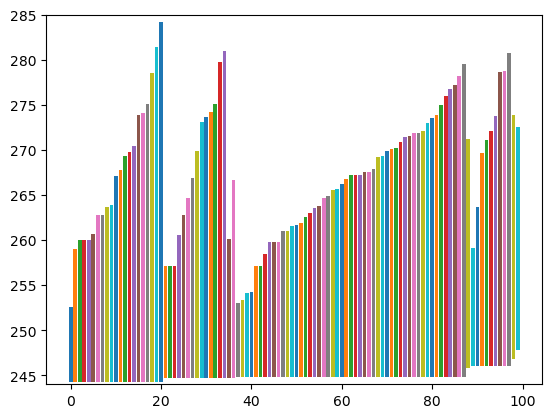

In [64]:
fig, ax = plt.subplots()

for d, dir_name in enumerate(df_check_history.sort('fitness_after', 'fitness_before')['dir']):
    df = df_check_history.filter(df_check_history['dir'] == dir_name)
    # ax.plot([d, d], [df['fitness_before'], df['fitness_after']])
    ax.bar(d, height=(df['fitness_before']-df['fitness_after']), bottom=df['fitness_after'])
ax.set_ylim(244, 285)
plt.show()

Most coefficients have moved to a fitness of around 245. Assume that the best answer is somewhere around there. The coefficients have all reached that similar level regardless of whether their fitness before was around 250 or around 270.

### Full results

View results for all 100 sets:

In [40]:
with pl.Config(set_tbl_rows=100):
    display(df_best_nudged.sort('fitness'))

age_less65_q00,age_65_q00,age_70_q00,age_75_q00,age_over80_q00,age_less65_q02,age_65_q02,age_70_q02,age_75_q02,age_over80_q02,age_less65_q04,age_65_q04,age_70_q04,age_75_q04,age_over80_q04,age_less65_q06,age_65_q06,age_70_q06,age_75_q06,age_over80_q06,age_less65_q08,age_65_q08,age_70_q08,age_75_q08,age_over80_q08,sum_sqres,wrong_rat,fitness,wrong_rat_under65,wrong_rat_65,wrong_rat_70,wrong_rat_75,wrong_rat_over80,sum_sqres_q00,sum_sqres_q02,sum_sqres_q04,sum_sqres_q06,sum_sqres_q08,dir
f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,str
0.0006,0.005,0.005,0.007,0.012,0.0005,0.003,0.004,0.007,0.012,0.0003,0.002,0.004,0.006,0.012,0.0003,0.002,0.004,0.005,0.011,0.0003,0.002,0.002,0.005,0.011,238.79332,1.022947,244.272812,0.991408,1.000036,0.990317,0.99959,0.995774,112.83844,109.368827,106.038015,103.869578,101.46549,"""randomseed09"""
0.0006,0.005,0.005,0.007,0.012,0.0005,0.003,0.004,0.007,0.012,0.0003,0.002,0.004,0.006,0.012,0.0003,0.002,0.004,0.005,0.011,0.0003,0.002,0.002,0.005,0.011,238.79332,1.022947,244.272812,0.991408,1.000036,0.990317,0.99959,0.995774,112.83844,109.368827,106.038015,103.869578,101.46549,"""randomseed12"""
0.0006,0.005,0.005,0.007,0.012,0.0005,0.003,0.004,0.007,0.012,0.0003,0.002,0.004,0.006,0.012,0.0003,0.002,0.004,0.005,0.011,0.0003,0.002,0.002,0.005,0.011,238.79332,1.022947,244.272812,0.991408,1.000036,0.990317,0.99959,0.995774,112.83844,109.368827,106.038015,103.869578,101.46549,"""randomseed49"""
0.0006,0.005,0.005,0.007,0.012,0.0005,0.003,0.004,0.007,0.012,0.0003,0.002,0.004,0.006,0.012,0.0003,0.002,0.004,0.005,0.011,0.0003,0.002,0.002,0.005,0.011,238.79332,1.022947,244.272812,0.991408,1.000036,0.990317,0.99959,0.995774,112.83844,109.368827,106.038015,103.869578,101.46549,"""randomseed72"""
0.0006,0.005,0.005,0.007,0.012,0.0005,0.003,0.004,0.007,0.012,0.0003,0.002,0.004,0.006,0.012,0.0003,0.002,0.004,0.005,0.011,0.0003,0.002,0.002,0.005,0.011,238.79332,1.022947,244.272812,0.991408,1.000036,0.990317,0.99959,0.995774,112.83844,109.368827,106.038015,103.869578,101.46549,"""randomseed00"""
0.0006,0.005,0.005,0.007,0.012,0.0005,0.003,0.004,0.007,0.012,0.0003,0.002,0.004,0.006,0.012,0.0003,0.002,0.004,0.005,0.011,0.0003,0.002,0.002,0.005,0.011,238.79332,1.022947,244.272812,0.991408,1.000036,0.990317,0.99959,0.995774,112.83844,109.368827,106.038015,103.869578,101.46549,"""randomseed08"""
0.0006,0.005,0.005,0.007,0.012,0.0005,0.003,0.004,0.007,0.012,0.0003,0.002,0.004,0.006,0.012,0.0003,0.002,0.004,0.005,0.011,0.0003,0.002,0.002,0.005,0.011,238.79332,1.022947,244.272812,0.991408,1.000036,0.990317,0.99959,0.995774,112.83844,109.368827,106.038015,103.869578,101.46549,"""randomseed14"""
0.0006,0.005,0.005,0.007,0.012,0.0005,0.003,0.004,0.007,0.012,0.0003,0.002,0.004,0.006,0.012,0.0003,0.002,0.004,0.005,0.011,0.0003,0.002,0.002,0.005,0.011,238.79332,1.022947,244.272812,0.991408,1.000036,0.990317,0.99959,0.995774,112.83844,109.368827,106.038015,103.869578,101.46549,"""randomseed21"""
0.0006,0.005,0.005,0.007,0.012,0.0005,0.003,0.004,0.007,0.012,0.0003,0.002,0.004,0.006,0.012,0.0003,0.002,0.004,0.005,0.011,0.0003,0.002,0.002,0.005,0.011,238.79332,1.022947,244.272812,0.991408,1.000036,0.990317,0.99959,0.995774,112.83844,109.368827,106.038015,103.869578,101.46549,"""randomseed30"""


View the set of coefficients in the starting set with the best fitness:

In [41]:
df_best_gens.sort('fitness')[0][coeff_names].to_numpy().flatten().reshape(5, 5)

array([[0.0005, 0.004 , 0.004 , 0.007 , 0.014 ],
       [0.0004, 0.003 , 0.004 , 0.007 , 0.013 ],
       [0.0004, 0.003 , 0.004 , 0.006 , 0.012 ],
       [0.0004, 0.002 , 0.004 , 0.005 , 0.01  ],
       [0.0003, 0.002 , 0.003 , 0.005 , 0.01  ]])

View the best set of coefficients after nudging:

In [42]:
best_nudged_fitness = df_best_nudged['fitness'].min()
best_nudged_coeffs = df_best_nudged.sort('fitness')[0][coeff_names].to_numpy().flatten()

# Pick out the names of sets that meet the best fitness:
mask = np.round(df_best_nudged['fitness'], 5) == np.round(best_nudged_fitness, 5)
best_dirs = df_best_nudged.filter(mask).sort('fitness')['dir'].to_numpy().flatten()

print(best_nudged_coeffs.reshape(5, 5))

[[0.0006 0.005  0.005  0.007  0.012 ]
 [0.0005 0.003  0.004  0.007  0.012 ]
 [0.0003 0.002  0.004  0.006  0.012 ]
 [0.0003 0.002  0.004  0.005  0.011 ]
 [0.0003 0.002  0.002  0.005  0.011 ]]


View the set(s) of coefficients that led to this best set:

In [43]:
for d in best_dirs:
    print(d)
    start_coeffs = df_best_gens.filter(df_best_gens['dir'] == d)[coeff_names].to_numpy().flatten()
    print(start_coeffs.reshape(5, 5))
    print('Nudges to reach best values:')
    print(best_nudged_coeffs.reshape(5, 5) - start_coeffs.reshape(5, 5))
    print('')

randomseed09
[[0.0005 0.003  0.004  0.007  0.014 ]
 [0.0005 0.003  0.004  0.006  0.013 ]
 [0.0004 0.003  0.004  0.006  0.012 ]
 [0.0004 0.003  0.004  0.005  0.011 ]
 [0.0004 0.002  0.003  0.005  0.01  ]]
Nudges to reach best values:
[[ 0.0001  0.002   0.001   0.     -0.002 ]
 [ 0.      0.      0.      0.001  -0.001 ]
 [-0.0001 -0.001   0.      0.      0.    ]
 [-0.0001 -0.001   0.      0.      0.    ]
 [-0.0001  0.     -0.001   0.      0.001 ]]

randomseed12
[[0.0005 0.004  0.004  0.007  0.015 ]
 [0.0004 0.003  0.004  0.007  0.013 ]
 [0.0004 0.003  0.004  0.006  0.012 ]
 [0.0004 0.003  0.004  0.005  0.01  ]
 [0.0004 0.002  0.003  0.005  0.01  ]]
Nudges to reach best values:
[[ 0.0001  0.001   0.001   0.     -0.003 ]
 [ 0.0001  0.      0.      0.     -0.001 ]
 [-0.0001 -0.001   0.      0.      0.    ]
 [-0.0001 -0.001   0.      0.      0.001 ]
 [-0.0001  0.     -0.001   0.      0.001 ]]

randomseed49
[[0.0005 0.003  0.004  0.008  0.014 ]
 [0.0004 0.003  0.004  0.006  0.014 ]
 [0.0004 0.

How many unique sets of coefficients are there?

In [65]:
coeffs_unique = np.unique(np.round(df_best_nudged[coeff_names], 4), axis=0)
# coeffs_unique = np.unique(np.round(df_best_nudged.filter(df_best_nudged['fitness'] <= 245)[coeff_names], 4), axis=0)

print(len(coeffs_unique))

8


In [66]:
for i, coeffs in enumerate(coeffs_unique):
    print(coeffs.reshape(5, 5))
    print(best_nudged_coeffs.reshape(5, 5) - coeffs.reshape(5, 5))
    print('\n')

[[0.0004 0.005  0.005  0.009  0.014 ]
 [0.0004 0.003  0.004  0.008  0.012 ]
 [0.0004 0.002  0.004  0.005  0.012 ]
 [0.0004 0.002  0.003  0.005  0.011 ]
 [0.0004 0.002  0.003  0.004  0.01  ]]
[[ 0.0002  0.      0.     -0.002  -0.002 ]
 [ 0.0001  0.      0.     -0.001   0.    ]
 [-0.0001  0.      0.      0.001   0.    ]
 [-0.0001  0.      0.001   0.      0.    ]
 [-0.0001  0.     -0.001   0.001   0.001 ]]


[[0.0005 0.004  0.004  0.007  0.015 ]
 [0.0005 0.004  0.004  0.007  0.011 ]
 [0.0004 0.002  0.004  0.006  0.011 ]
 [0.0003 0.002  0.004  0.005  0.011 ]
 [0.0003 0.002  0.003  0.005  0.011 ]]
[[ 0.0001  0.001   0.001   0.     -0.003 ]
 [ 0.     -0.001   0.      0.      0.001 ]
 [-0.0001  0.      0.      0.      0.001 ]
 [ 0.      0.      0.      0.      0.    ]
 [ 0.      0.     -0.001   0.      0.    ]]


[[0.0005 0.004  0.004  0.009  0.014 ]
 [0.0004 0.004  0.004  0.007  0.012 ]
 [0.0004 0.002  0.004  0.007  0.011 ]
 [0.0004 0.002  0.004  0.004  0.011 ]
 [0.0003 0.002  0.003  0.004  

In [67]:
df_unique = pl.DataFrame(coeffs_unique, schema=coeff_names)

In [68]:
df_unique

age_less65_q00,age_65_q00,age_70_q00,age_75_q00,age_over80_q00,age_less65_q02,age_65_q02,age_70_q02,age_75_q02,age_over80_q02,age_less65_q04,age_65_q04,age_70_q04,age_75_q04,age_over80_q04,age_less65_q06,age_65_q06,age_70_q06,age_75_q06,age_over80_q06,age_less65_q08,age_65_q08,age_70_q08,age_75_q08,age_over80_q08
f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
0.0004,0.005,0.005,0.009,0.014,0.0004,0.003,0.004,0.008,0.012,0.0004,0.002,0.004,0.005,0.012,0.0004,0.002,0.003,0.005,0.011,0.0004,0.002,0.003,0.004,0.01
0.0005,0.004,0.004,0.007,0.015,0.0005,0.004,0.004,0.007,0.011,0.0004,0.002,0.004,0.006,0.011,0.0003,0.002,0.004,0.005,0.011,0.0003,0.002,0.003,0.005,0.011
0.0005,0.004,0.004,0.009,0.014,0.0004,0.004,0.004,0.007,0.012,0.0004,0.002,0.004,0.007,0.011,0.0004,0.002,0.004,0.004,0.011,0.0003,0.002,0.003,0.004,0.011
0.0005,0.005,0.005,0.007,0.013,0.0004,0.003,0.004,0.007,0.013,0.0004,0.002,0.004,0.006,0.011,0.0004,0.002,0.003,0.005,0.011,0.0003,0.002,0.003,0.005,0.011
0.0005,0.005,0.005,0.007,0.014,0.0005,0.003,0.004,0.007,0.012,0.0004,0.002,0.004,0.006,0.011,0.0003,0.002,0.003,0.006,0.011,0.0003,0.002,0.003,0.004,0.011
0.0005,0.005,0.005,0.007,0.014,0.0005,0.003,0.004,0.007,0.012,0.0004,0.002,0.004,0.006,0.011,0.0004,0.002,0.003,0.005,0.011,0.0002,0.002,0.003,0.005,0.011
0.0006,0.004,0.004,0.007,0.014,0.0004,0.004,0.004,0.007,0.012,0.0004,0.002,0.004,0.006,0.011,0.0003,0.002,0.004,0.005,0.011,0.0003,0.002,0.003,0.005,0.011
0.0006,0.005,0.005,0.007,0.012,0.0005,0.003,0.004,0.007,0.012,0.0003,0.002,0.004,0.006,0.012,0.0003,0.002,0.004,0.005,0.011,0.0003,0.002,0.002,0.005,0.011


In [69]:
pl.DataFrame(np.round(best_nudged_coeffs - df_unique, 4), schema=coeff_names)

age_less65_q00,age_65_q00,age_70_q00,age_75_q00,age_over80_q00,age_less65_q02,age_65_q02,age_70_q02,age_75_q02,age_over80_q02,age_less65_q04,age_65_q04,age_70_q04,age_75_q04,age_over80_q04,age_less65_q06,age_65_q06,age_70_q06,age_75_q06,age_over80_q06,age_less65_q08,age_65_q08,age_70_q08,age_75_q08,age_over80_q08
f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
0.0002,0.0,0.0,-0.002,-0.002,0.0001,0.0,0.0,-0.001,0.0,-0.0001,0.0,0.0,0.001,0.0,-0.0001,0.0,0.001,0.0,0.0,-0.0001,0.0,-0.001,0.001,0.001
0.0001,0.001,0.001,0.0,-0.003,0.0,-0.001,0.0,0.0,0.001,-0.0001,0.0,0.0,0.0,0.001,0.0,0.0,0.0,0.0,0.0,0.0,0.0,-0.001,0.0,0.0
0.0001,0.001,0.001,-0.002,-0.002,0.0001,-0.001,0.0,0.0,0.0,-0.0001,0.0,0.0,-0.001,0.001,-0.0001,0.0,0.0,0.001,0.0,0.0,0.0,-0.001,0.001,0.0
0.0001,0.0,0.0,0.0,-0.001,0.0001,0.0,0.0,0.0,-0.001,-0.0001,0.0,0.0,0.0,0.001,-0.0001,0.0,0.001,0.0,0.0,0.0,0.0,-0.001,0.0,0.0
0.0001,0.0,0.0,0.0,-0.002,0.0,0.0,0.0,0.0,0.0,-0.0001,0.0,0.0,0.0,0.001,0.0,0.0,0.001,-0.001,0.0,0.0,0.0,-0.001,0.001,0.0
0.0001,0.0,0.0,0.0,-0.002,0.0,0.0,0.0,0.0,0.0,-0.0001,0.0,0.0,0.0,0.001,-0.0001,0.0,0.001,0.0,0.0,0.0001,0.0,-0.001,0.0,0.0
0.0,0.001,0.001,0.0,-0.002,0.0001,-0.001,0.0,0.0,0.0,-0.0001,0.0,0.0,0.0,0.001,0.0,0.0,0.0,0.0,0.0,0.0,0.0,-0.001,0.0,0.0
0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [70]:
for i, coeffs in enumerate(coeffs_unique):
    print(coeffs)
    print(best_nudged_coeffs - coeffs)
    print('\n')

[0.0004 0.005  0.005  0.009  0.014  0.0004 0.003  0.004  0.008  0.012
 0.0004 0.002  0.004  0.005  0.012  0.0004 0.002  0.003  0.005  0.011
 0.0004 0.002  0.003  0.004  0.01  ]
[ 0.0002  0.      0.     -0.002  -0.002   0.0001  0.      0.     -0.001
  0.     -0.0001  0.      0.      0.001   0.     -0.0001  0.      0.001
  0.      0.     -0.0001  0.     -0.001   0.001   0.001 ]


[0.0005 0.004  0.004  0.007  0.015  0.0005 0.004  0.004  0.007  0.011
 0.0004 0.002  0.004  0.006  0.011  0.0003 0.002  0.004  0.005  0.011
 0.0003 0.002  0.003  0.005  0.011 ]
[ 0.0001  0.001   0.001   0.     -0.003   0.     -0.001   0.      0.
  0.001  -0.0001  0.      0.      0.      0.001   0.      0.      0.
  0.      0.      0.      0.     -0.001   0.      0.    ]


[0.0005 0.004  0.004  0.009  0.014  0.0004 0.004  0.004  0.007  0.012
 0.0004 0.002  0.004  0.007  0.011  0.0004 0.002  0.004  0.004  0.011
 0.0003 0.002  0.003  0.004  0.011 ]
[ 0.0001  0.001   0.001  -0.002  -0.002   0.0001 -0.001   0.      0

View range of values in the final nudged set:

In [71]:
print(best_nudged_coeffs.reshape(5, 5))

[[0.0006 0.005  0.005  0.007  0.012 ]
 [0.0005 0.003  0.004  0.007  0.012 ]
 [0.0003 0.002  0.004  0.006  0.012 ]
 [0.0003 0.002  0.004  0.005  0.011 ]
 [0.0003 0.002  0.002  0.005  0.011 ]]


In [72]:
df = df_best_nudged.drop('dir')

print(df[coeff_names].mean().to_numpy().flatten().reshape(5, 5))

[[0.000529 0.00489  0.00489  0.00704  0.01308 ]
 [0.000438 0.00311  0.004    0.00701  0.0125  ]
 [0.000379 0.002    0.004    0.006    0.01122 ]
 [0.000367 0.002    0.00332  0.00501  0.011   ]
 [0.000287 0.002    0.00279  0.00496  0.01099 ]]


The mean across the 100 results is not that far off the best set, i.e. most of the 100 results agree on the values.

In [73]:
print(df[coeff_names].std().to_numpy().flatten().reshape(5, 5))
print((100.0*df.std() / df.mean())[coeff_names].to_numpy().flatten().reshape(5, 5))

[[0.00004777 0.00031447 0.00031447 0.00028141 0.00072027]
 [0.00004878 0.00031447 0.         0.0001     0.00052223]
 [0.00004094 0.         0.         0.00014213 0.00041633]
 [0.00004726 0.         0.00046883 0.00017379 0.        ]
 [0.00003667 0.         0.00040936 0.00019695 0.0001    ]]
[[ 9.02993962  6.43079832  6.43079832  3.99730949  5.5066461 ]
 [11.13771076 10.11144816  0.          1.42653352  4.17786374]
 [10.80106018  0.          0.          2.36889685  3.71063458]
 [12.87688182  0.         14.12127025  3.46880807  0.        ]
 [12.77584204  0.         14.67240791  3.97069326  0.90991811]]


Plot the nudged coefficients:

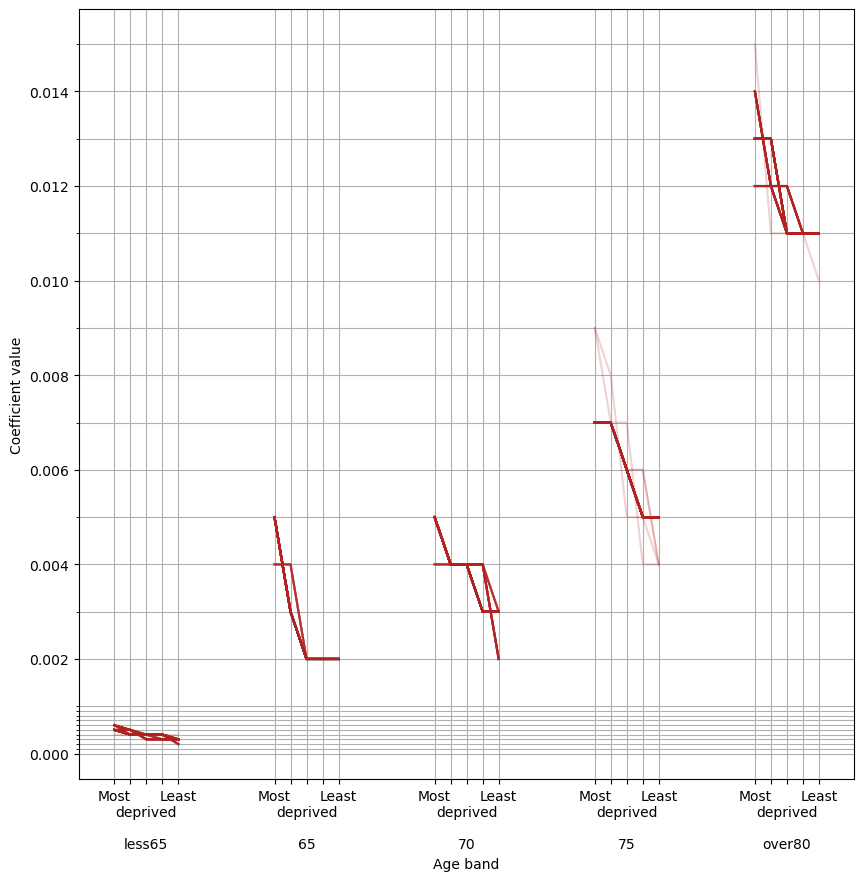

In [74]:
age_bands = ['less65', '65', '70', '75', 'over80']
x_offsets = np.arange(-0.2, 0.3, 0.1)
xticks_minor = np.concatenate([x_offsets + a for a in range(len(age_bands))])

qmin_labels = np.concatenate([['Most', '', '' + '\ndeprived\n\n' + age_band, '', 'Least'] for age_band in age_bands])

np.random.seed(42)
fig, ax = plt.subplots(figsize=(10, 10))

# for results_dir in df_best_nudged.filter(df_best_nudged['fitness'] <= 245)['dir']:  # results_dirs_to_merge:
for results_dir in df_best_nudged['dir']:  # results_dirs_to_merge:
    # Pick out coeffs:
    coeffs = df_best_nudged.filter(df_best_nudged['dir'] == results_dir)[coeff_names].to_numpy().flatten()
    # if results_dir in df_best_gens_topr2['dir']:
    # colour = np.random.rand(3,)
    # zorder = 5
    # alpha = 1.0
    # else:
    colour = 'FireBrick'
    zorder = 4
    alpha = 0.2
    # g = gen_attr(df_coeffs_init)

    offset = -0.2
    for c in range(5):
        # xs = np.arange(5) + offset
        # ys = g[c*5:(c*5)+5]
        xs = np.arange(-0.2, 0.3, 0.1) + c
        
        ys = np.array(coeffs)[np.arange(0, 25, 5) + c]# * np.array([coeffs_ssnap[c]] * 5)
        ax.plot(xs, ys, color=colour, zorder=zorder, alpha=alpha, label=(results_dir if c==0 else None))
        offset += 0.1


ax.set_xticks(xticks_minor)
ax.set_xticklabels(qmin_labels)

ylim = ax.get_ylim()
yticks = list(ax.get_yticks())
ax.set_yticks(yticks)
yticks_min = np.concatenate((np.arange(0.0, 1e-3, 1e-4), np.arange(1e-3, yticks[-1], 1e-3)))
ax.set_yticks(yticks_min, minor=True)
ax.set_ylim(ylim)

ax.grid(visible=True, axis='x')
ax.grid(visible=True, axis='y', which='both')

ax.set_xlabel('Age band')
ax.set_ylabel('Coefficient value')

# Save:
# plt.savefig('./images/scatter_coeffs_from_deap_nudged.png', bbox_inches='tight')
plt.show()

Split the coefficients into their age bands. Then don't compare the full set of 25, but just the 5 coefficients in an age band. There are far fewer options when there are only five coefficients.

How many sets of coefficients fall into each option?

In [75]:
age_bands = ['less65', '65', '70', '75', 'over80']
for age in age_bands:
    cols_here = [c for c in df_best_nudged.columns if f'_{age}_' in c]
    options = np.unique(np.round(df_best_nudged[cols_here], 4), axis=0)
    
    print(f'Age band: {age}')
    for coeff_list in options:
        mask = np.all(np.round(df_best_nudged[cols_here].to_numpy(), 4) == np.round(coeff_list, 4), axis=1)
        dirs = df_best_nudged.filter(mask)['dir'].to_numpy()
        print(coeff_list, len(dirs))#, dirs)
    print('\n')

Age band: less65
[0.0004 0.0004 0.0004 0.0004 0.0004] 1
[0.0005 0.0004 0.0004 0.0004 0.0003] 52
[0.0005 0.0005 0.0004 0.0003 0.0003] 3
[0.0005 0.0005 0.0004 0.0004 0.0002] 14
[0.0006 0.0004 0.0004 0.0003 0.0003] 9
[0.0006 0.0005 0.0003 0.0003 0.0003] 21


Age band: 65
[0.004 0.004 0.002 0.002 0.002] 11
[0.005 0.003 0.002 0.002 0.002] 89


Age band: 70
[0.004 0.004 0.004 0.004 0.003] 11
[0.005 0.004 0.004 0.003 0.003] 68
[0.005 0.004 0.004 0.004 0.002] 21


Age band: 75
[0.007 0.007 0.006 0.005 0.005] 96
[0.007 0.007 0.006 0.006 0.004] 2
[0.009 0.007 0.007 0.004 0.004] 1
[0.009 0.008 0.005 0.005 0.004] 1


Age band: over80
[0.012 0.012 0.012 0.011 0.011] 21
[0.013 0.013 0.011 0.011 0.011] 51
[0.014 0.012 0.011 0.011 0.011] 26
[0.014 0.012 0.012 0.011 0.01 ] 1
[0.015 0.011 0.011 0.011 0.011] 1




In [76]:
print(best_nudged_coeffs.reshape(5, 5))

[[0.0006 0.005  0.005  0.007  0.012 ]
 [0.0005 0.003  0.004  0.007  0.012 ]
 [0.0003 0.002  0.004  0.006  0.012 ]
 [0.0003 0.002  0.004  0.005  0.011 ]
 [0.0003 0.002  0.002  0.005  0.011 ]]
